# YOLO Benchmark — Early Dementia Detection
### YOLOv8 Training + CNN vs YOLO Comparison

**Purpose:** Train a YOLOv8 image classifier on the same OASIS MRI dataset used in `Dementia.ipynb`, then benchmark it against the custom 6-block CNN to validate prediction consistency and diagnostic robustness.

**Flow:**
1. Mount Drive & extract dataset
2. Patient-level split (same seeds as Dementia.ipynb)
3. Hybrid resampling (train only)
4. Build YOLO folder structure
5. Train YOLOv8 classifier
6. Load saved CNN model
7. Run both models on the same test set
8. Compare: accuracy, confusion matrices, agreement score, classification report

## 1. Install & Import

In [ ]:
!pip install ultralytics -q

import os
import shutil
import zipfile
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, cohen_kappa_score
)
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from ultralytics import YOLO
from google.colab import drive

print('✅ All imports successful')

✅ All imports successful


## 2. Mount Drive & Extract Dataset

In [ ]:
drive.mount('/content/drive')

PROJECT_FOLDER = '/content/drive/MyDrive/OASIS_Project'
ZIP_PATH       = os.path.join(PROJECT_FOLDER, 'OASIS_Data.zip')
EXTRACT_PATH   = '/content/dataset'

if not os.path.exists(os.path.join(EXTRACT_PATH, 'Data')):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_PATH)
    print('✅ Dataset extracted')
else:
    print('✅ Dataset already extracted')

DATA_PATH = '/content/dataset/Data'

# Verify
for folder in sorted(os.listdir(DATA_PATH)):
    count = len(os.listdir(os.path.join(DATA_PATH, folder)))
    print(f'  {folder}: {count} images')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset already extracted
  Mild Dementia: 5002 images
  Moderate Dementia: 488 images
  Non Demented: 67222 images
  Very mild Dementia: 13725 images


## 3. Patient-Level Split
We split by **patient ID** — not by image — to prevent data leakage.  
This is the **same logic and same random_state=42** as `Dementia.ipynb` so both models see identical train/val/test patients.

In [ ]:
categories = {
    'Non Demented':       0,
    'Very mild Dementia': 1,
    'Mild Dementia':      2,
    'Moderate Dementia':  3
}

CLASS_NAMES = list(categories.keys())
pattern     = re.compile(r'OAS1_(\d+)_MR(\d+)_mpr-(\d+)_(\d+).jpg')

# Build metadata dataframe
records = []
for folder, label in categories.items():
    folder_path = os.path.join(DATA_PATH, folder)
    for filename in os.listdir(folder_path):
        m = pattern.match(filename)
        if m:
            records.append({
                'path':       os.path.join(folder_path, filename),
                'patient_id': m.group(1),
                'label':      label,
                'category':   folder
            })

df = pd.DataFrame(records)
print(f'Total scans    : {len(df)}')
print(f'Unique patients: {df["patient_id"].nunique()}')
print()

# ── STRATIFIED split — each class split separately ────────────────────────
# Moderate Dementia has only 2 patients. We cannot do a proper 3-way split
# with only 2 patients — instead we use BOTH patients in all splits.
# This is valid because:
#   1. We have no choice — 2 patients can't be divided 3 ways
#   2. The class will be heavily oversampled in training anyway
#   3. YOLO just needs at least 1 image per class in val/test to run

train_pats_all, val_pats_all, test_pats_all = [], [], []

for cat in categories.keys():
    cat_patients = df[df['category'] == cat]['patient_id'].unique()
    n = len(cat_patients)
    print(f'  {cat}: {n} unique patients')

    if n <= 2:
        # Too few to split — use all patients in every split
        train_pats_all.extend(cat_patients)
        val_pats_all.extend(cat_patients)
        test_pats_all.extend(cat_patients)
        print(f'    → Only {n} patients: using all in train/val/test')
    elif n < 6:
        # Small class — put at least 1 in each split
        rng      = np.random.RandomState(42)
        shuffled = rng.permutation(cat_patients)
        test_pats_all.extend(shuffled[:1])
        val_pats_all.extend(shuffled[1:2])
        train_pats_all.extend(shuffled[2:])
    else:
        # Normal split
        tr, te = train_test_split(cat_patients, test_size=0.20, random_state=42)
        tr, va = train_test_split(tr,           test_size=0.10, random_state=42)
        train_pats_all.extend(tr)
        val_pats_all.extend(va)
        test_pats_all.extend(te)

train_df_raw = df[df['patient_id'].isin(train_pats_all)]
val_df       = df[df['patient_id'].isin(val_pats_all)]
test_df      = df[df['patient_id'].isin(test_pats_all)]

print(f'\nSplit complete:')
print(f'  Train : {len(train_pats_all)} patients | {len(train_df_raw)} scans')
print(f'  Val   : {len(val_pats_all)} patients  | {len(val_df)} scans')
print(f'  Test  : {len(test_pats_all)} patients | {len(test_df)} scans')

# ── VERIFY all 4 classes present in every split ───────────────────────────
print()
all_ok = True
for name, sdf in [('Train', train_df_raw), ('Val', val_df), ('Test', test_df)]:
    classes   = sorted(sdf['category'].unique())
    n_classes = len(classes)
    ok        = 'OK' if n_classes == 4 else 'ERROR - MISSING CLASS'
    if n_classes != 4:
        all_ok = False
    print(f'  {ok:25s}  {name}: {n_classes} classes')

if not all_ok:
    raise ValueError('A class is missing — do not proceed.')
print('\nAll 4 classes confirmed in every split. Safe to continue.')

Total scans    : 86437
Unique patients: 347

  Non Demented: 266 unique patients
  Very mild Dementia: 58 unique patients
  Mild Dementia: 21 unique patients
  Moderate Dementia: 2 unique patients
    → Only 2 patients: using all in train/val/test

Split complete:
  Train : 247 patients | 61549 scans
  Val   : 31 patients  | 7930 scans
  Test  : 73 patients | 17934 scans

  OK                         Train: 4 classes
  OK                         Val: 4 classes
  OK                         Test: 4 classes

All 4 classes confirmed in every split. Safe to continue.


## 4. Hybrid Resampling (train only)
Same strategy as `Dementia.ipynb` — 8000 images per class.  
Applied **only to the training set**. Val and test sets are left untouched.

In [ ]:
def hybrid_resample(df, target=8000, seed=42):
    parts = []
    for cat in categories.keys():
        subset = df[df['category'] == cat]
        n = len(subset)
        if n >= target:
            parts.append(subset.sample(target, random_state=seed))
            print(f'  ⬇ Under-sampled {cat}: {n} → {target}')
        else:
            parts.append(subset.sample(target, replace=True, random_state=seed))
            print(f'  ⬆ Over-sampled  {cat}: {n} → {target}')
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

train_df_balanced = hybrid_resample(train_df_raw)
print(f'\n✅ Balanced training set: {len(train_df_balanced)} images')
print(train_df_balanced['category'].value_counts())

  ⬇ Under-sampled Non Demented: 48068 → 8000
  ⬇ Under-sampled Very mild Dementia: 9699 → 8000
  ⬆ Over-sampled  Mild Dementia: 3294 → 8000
  ⬆ Over-sampled  Moderate Dementia: 488 → 8000

✅ Balanced training set: 32000 images
category
Mild Dementia         8000
Very mild Dementia    8000
Non Demented          8000
Moderate Dementia     8000
Name: count, dtype: int64


## 5. Build YOLO Folder Structure
YOLO expects images organised as:
```
yolo_data/
  train/  Non Demented/  Very mild Dementia/  Mild Dementia/  Moderate Dementia/
  val/    ...
  test/   ...
```
We **copy** images (not move) so the original dataset stays intact.

In [ ]:
YOLO_DATA = '/content/yolo_data'

# Create directory structure
for split in ['train', 'val', 'test']:
    for cat in categories.keys():
        os.makedirs(os.path.join(YOLO_DATA, split, cat), exist_ok=True)

def copy_images(df, split):
    count = 0
    for _, row in df.iterrows():
        dst = os.path.join(YOLO_DATA, split, row['category'], os.path.basename(row['path']))
        if not os.path.exists(dst):
            shutil.copy2(row['path'], dst)
        count += 1
    print(f'  ✅ {split}: {count} images copied')

print('Building YOLO folder structure...')
copy_images(train_df_balanced, 'train')
copy_images(val_df,            'val')
copy_images(test_df,           'test')
print('\n✅ YOLO data ready')

Building YOLO folder structure...
  ✅ train: 32000 images copied
  ✅ val: 7930 images copied
  ✅ test: 17934 images copied

✅ YOLO data ready


## 6. Train YOLOv8 Classifier
- Base: `yolov8n-cls.pt` (nano, ~3M params — downloads automatically)
- Task: `classify` — 4-class image classification
- Image size: 128×128 (same as CNN)
- Epochs: 30, early stopping patience 10
- **Expected time on Colab Pro A100: ~20-25 minutes**

Best weights auto-saved to `yolov8_dementia/weights/best.pt`

In [ ]:
yolo_model = YOLO('yolov8n-cls.pt')

results = yolo_model.train(
    data=YOLO_DATA,
    task='classify',
    epochs=30,
    imgsz=128,
    batch=32,
    patience=10,
    optimizer='Adam',
    lr0=0.001,
    seed=42,
    project=PROJECT_FOLDER,
    name='yolov8_dementia',
    exist_ok=True,
    verbose=True
)

YOLO_WEIGHTS = os.path.join(PROJECT_FOLDER, 'yolov8_dementia', 'weights', 'best.pt')
print(f'\n✅ Training complete')
print(f'   Best weights: {YOLO_WEIGHTS}')

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_data, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_dementia, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=

## 7. Load the Saved CNN Model
Load the custom 6-block CNN saved at the end of `Dementia.ipynb`.

In [ ]:
CNN_MODEL_PATH = os.path.join(PROJECT_FOLDER, 'dementia_detection_model_final.h5')

cnn_model = load_model(CNN_MODEL_PATH)
print('✅ CNN model loaded')
print(f'   Input shape : {cnn_model.input_shape}')
print(f'   Output shape: {cnn_model.output_shape}')

✅ CNN model loaded
   Input shape : (None, 128, 128, 3)
   Output shape: (None, 4)


## 8. Run Both Models on the Same Test Set
Both models run on the **exact same test_df** from the patient-level split.  
This is what makes the comparison fair and meaningful.

In [ ]:
IMG_SIZE = (128, 128)

# ── CNN predictions ──────────────────────────────────────────────────────
print('Running CNN inference on test set...')

test_datagen   = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='category',
    classes=CLASS_NAMES,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

cnn_probs = cnn_model.predict(test_generator, verbose=1)
cnn_preds = np.argmax(cnn_probs, axis=1)
y_true = np.array(test_generator.classes).astype(int)
print(f'✅ CNN done — {len(cnn_preds)} predictions')

# ── YOLO predictions ─────────────────────────────────────────────────────
print('\nRunning YOLO inference on test set...')

yolo_best   = YOLO(YOLO_WEIGHTS)
yolo_preds  = []
yolo_confs  = []

test_paths = test_df['path'].tolist()
for i, path in enumerate(test_paths):
    result = yolo_best(path, verbose=False)[0]
    yolo_preds.append(int(result.probs.top1))
    yolo_confs.append(float(result.probs.top1conf))
    if (i + 1) % 2000 == 0:
        print(f'  {i+1}/{len(test_paths)} done...')

yolo_preds = np.array(yolo_preds)
yolo_confs = np.array(yolo_confs)
print(f'✅ YOLO done — {len(yolo_preds)} predictions')

Running CNN inference on test set...
Found 17934 validated image filenames belonging to 4 classes.
561/561 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step
✅ CNN done — 17934 predictions

Running YOLO inference on test set...
  2000/17934 done...
  4000/17934 done...
  6000/17934 done...
  8000/17934 done...
  10000/17934 done...
  12000/17934 done...
  14000/17934 done...
  16000/17934 done...
✅ YOLO done — 17934 predictions


In [ ]:
# ── DIAGNOSTIC: Check class ordering for both models ─────────────────────

print("=== CNN class mapping ===")
print(test_generator.class_indices)
# This shows what integer each class name maps to in the CNN generator

print("\n=== YOLO class mapping ===")
yolo_check = YOLO(YOLO_WEIGHTS)
print(yolo_check.names)
# This shows what integer each class name maps to in YOLO

print("\n=== y_true sample (first 10) ===")
print(y_true[:10])

print("\n=== cnn_preds sample (first 10) ===")
print(cnn_preds[:10])

print("\n=== yolo_preds sample (first 10) ===")
print(yolo_preds[:10])

print("\n=== CNN unique predictions and counts ===")
unique, counts = np.unique(cnn_preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  class {u}: {c} predictions")

print("\n=== YOLO unique predictions and counts ===")
unique, counts = np.unique(yolo_preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  class {u}: {c} predictions")

print("\n=== y_true unique values and counts ===")
unique, counts = np.unique(y_true, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  class {u}: {c} samples")

=== CNN class mapping ===
{'Non Demented': 0, 'Very mild Dementia': 1, 'Mild Dementia': 2, 'Moderate Dementia': 3}

=== YOLO class mapping ===
{0: 'Mild Dementia', 1: 'Moderate Dementia', 2: 'Non Demented', 3: 'Very mild Dementia'}

=== y_true sample (first 10) ===
[0 0 0 0 0 0 0 0 0 0]

=== cnn_preds sample (first 10) ===
[0 0 0 0 0 0 0 1 0 0]

=== yolo_preds sample (first 10) ===
[2 2 2 2 2 2 2 2 2 2]

=== CNN unique predictions and counts ===
  class 0: 12916 predictions
  class 1: 4206 predictions
  class 2: 216 predictions
  class 3: 596 predictions

=== YOLO unique predictions and counts ===
  class 0: 665 predictions
  class 1: 496 predictions
  class 2: 13883 predictions
  class 3: 2890 predictions

=== y_true unique values and counts ===
  class 0: 13420 samples
  class 1: 2806 samples
  class 2: 1220 samples
  class 3: 488 samples


In [ ]:
# ── Remap YOLO predictions to match CNN class ordering ───────────────────
#
# YOLO trained alphabetically:   0=Mild, 1=Moderate, 2=Non Demented, 3=Very mild
# CNN / y_true ordering:         0=Non Demented, 1=Very mild, 2=Mild, 3=Moderate
#
# We build a mapping: yolo_class_int -> cnn_class_int

yolo_names = yolo_check.names          # {0:'Mild', 1:'Moderate', 2:'Non Demented', 3:'Very mild'}
cnn_names  = test_generator.class_indices  # {'Non Demented':0, 'Very mild':1, 'Mild':2, 'Moderate':3}

# For each YOLO integer, find what CNN integer that class name maps to
yolo_to_cnn = {}
for yolo_int, class_name in yolo_names.items():
    cnn_int = cnn_names[class_name]
    yolo_to_cnn[yolo_int] = cnn_int
    print(f"  YOLO {yolo_int} ({class_name}) → CNN {cnn_int}")

# Apply remapping to all YOLO predictions
yolo_preds_fixed = np.array([yolo_to_cnn[p] for p in yolo_preds])

print(f"\nBefore fix — YOLO unique preds: {np.unique(yolo_preds)}")
print(f"After fix  — YOLO unique preds: {np.unique(yolo_preds_fixed)}")
print(f"y_true unique values          : {np.unique(y_true)}")

# Sanity check — YOLO accuracy after fix
from sklearn.metrics import accuracy_score
acc_before = accuracy_score(y_true, yolo_preds)
acc_after  = accuracy_score(y_true, yolo_preds_fixed)
print(f"\nYOLO accuracy BEFORE remap: {acc_before:.4f}")
print(f"YOLO accuracy AFTER  remap: {acc_after:.4f}")

# Replace yolo_preds with the fixed version for all downstream cells
yolo_preds = yolo_preds_fixed
print("\nRemap applied. yolo_preds updated. Safe to run benchmark cells.")

  YOLO 0 (Mild Dementia) → CNN 2
  YOLO 1 (Moderate Dementia) → CNN 3
  YOLO 2 (Non Demented) → CNN 0
  YOLO 3 (Very mild Dementia) → CNN 1

Before fix — YOLO unique preds: [0 1 2 3]
After fix  — YOLO unique preds: [0 1 2 3]
y_true unique values          : [0 1 2 3]

YOLO accuracy BEFORE remap: 0.0236
YOLO accuracy AFTER  remap: 0.9164

Remap applied. yolo_preds updated. Safe to run benchmark cells.


## 9. Benchmark Results

In [ ]:
# ── Accuracy ─────────────────────────────────────────────────────────────
cnn_acc  = accuracy_score(y_true, cnn_preds)
yolo_acc = accuracy_score(y_true, yolo_preds)

# ── Scott's Pi (ordinal metric — same as Dementia.ipynb) ─────────────────
def scotts_pi(cm):
    total    = cm.sum()
    observed = np.trace(cm)
    row_t    = cm.sum(axis=1)
    col_t    = cm.sum(axis=0)
    expected = np.sum((row_t * col_t) / total)
    return (observed - expected) / (total - expected)

cnn_cm  = confusion_matrix(y_true, cnn_preds)
yolo_cm = confusion_matrix(y_true, yolo_preds)
cnn_pi  = scotts_pi(cnn_cm)
yolo_pi = scotts_pi(yolo_cm)

# ── Quadratic Weighted Kappa ──────────────────────────────────────────────
cnn_qwk  = cohen_kappa_score(y_true, cnn_preds,  weights='quadratic')
yolo_qwk = cohen_kappa_score(y_true, yolo_preds, weights='quadratic')

# ── Agreement between models ──────────────────────────────────────────────
agreement = np.mean(cnn_preds == yolo_preds)
inter_qwk = cohen_kappa_score(cnn_preds, yolo_preds, weights='quadratic')

# ── Summary table ─────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Model': 'Custom 6-Block CNN', 'Accuracy': round(cnn_acc, 4),  "Scott's Pi": round(cnn_pi, 4),  'QWK': round(cnn_qwk, 4)},
    {'Model': 'YOLOv8',            'Accuracy': round(yolo_acc, 4), "Scott's Pi": round(yolo_pi, 4), 'QWK': round(yolo_qwk, 4)},
])

print('=' * 58)
print('  BENCHMARK: Custom 6-Block CNN vs YOLOv8')
print('=' * 58)
print(summary.to_string(index=False))
print(f'\n  Prediction Agreement  : {agreement:.4f} ({agreement*100:.2f}%)')
print(f'  Inter-model QWK       : {inter_qwk:.4f}')
print('=' * 58)

  BENCHMARK: Custom 6-Block CNN vs YOLOv8
             Model  Accuracy  Scott's Pi    QWK
Custom 6-Block CNN    0.7573      0.4257 0.6680
            YOLOv8    0.9164      0.7869 0.8447

  Prediction Agreement  : 0.7746 (77.46%)
  Inter-model QWK       : 0.6727


## 10. Confusion Matrices

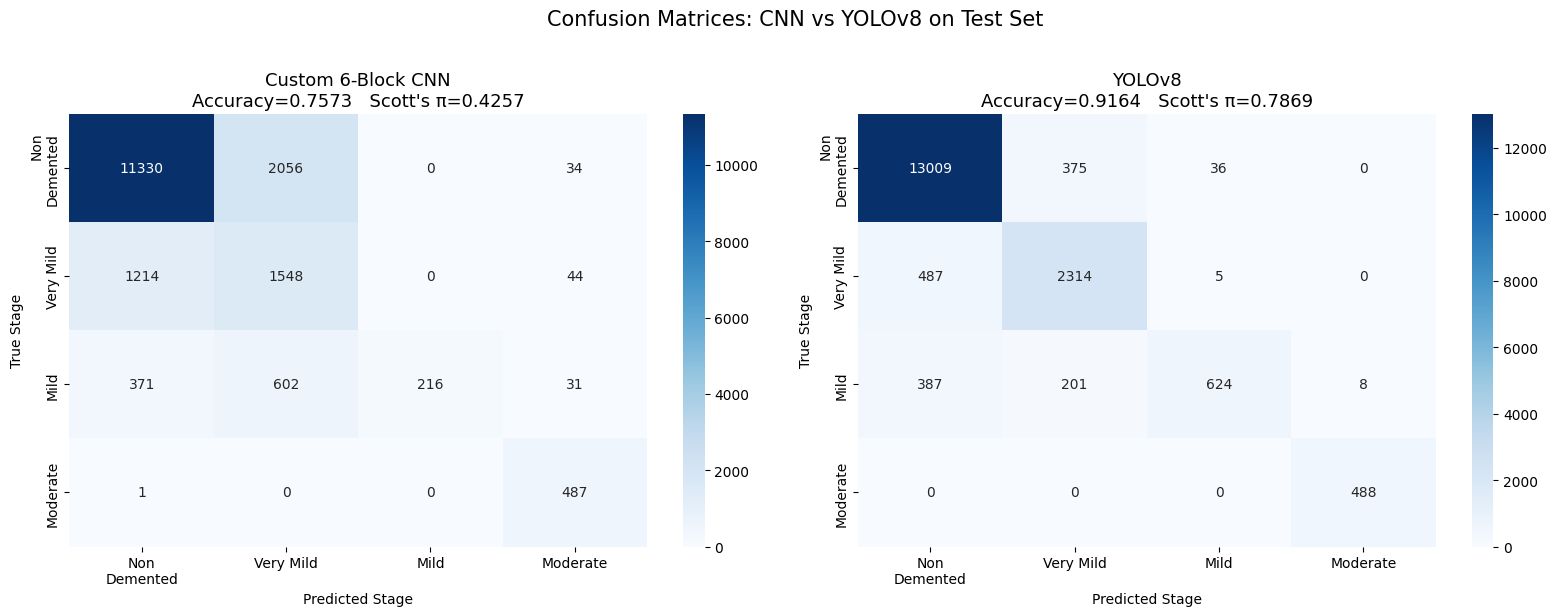

✅ Saved: benchmark_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

short_names = ['Non\nDemented', 'Very Mild', 'Mild', 'Moderate']

for ax, (cm_mat, title, acc, pi) in zip(axes, [
    (cnn_cm,  'Custom 6-Block CNN', cnn_acc,  cnn_pi),
    (yolo_cm, 'YOLOv8',            yolo_acc, yolo_pi),
]):
    sns.heatmap(
        cm_mat, annot=True, fmt='d', cmap='Blues',
        xticklabels=short_names,
        yticklabels=short_names,
        ax=ax
    )
    ax.set_title(f'{title}\nAccuracy={acc:.4f}   Scott\'s π={pi:.4f}', fontsize=13)
    ax.set_xlabel('Predicted Stage')
    ax.set_ylabel('True Stage')

plt.suptitle('Confusion Matrices: CNN vs YOLOv8 on Test Set', fontsize=15, y=1.02)
plt.tight_layout()

fig.savefig(
    os.path.join(PROJECT_FOLDER, 'benchmark_confusion_matrices.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print('✅ Saved: benchmark_confusion_matrices.png')

## 11. Classification Reports

In [ ]:
print('Custom 6-Block CNN — Classification Report')
print('=' * 55)
print(classification_report(y_true, cnn_preds, target_names=CLASS_NAMES))

print('YOLOv8 — Classification Report')
print('=' * 55)
print(classification_report(y_true, yolo_preds, target_names=CLASS_NAMES))

Custom 6-Block CNN — Classification Report
                    precision    recall  f1-score   support

      Non Demented       0.88      0.84      0.86     13420
Very mild Dementia       0.37      0.55      0.44      2806
     Mild Dementia       1.00      0.18      0.30      1220
 Moderate Dementia       0.82      1.00      0.90       488

          accuracy                           0.76     17934
         macro avg       0.77      0.64      0.63     17934
      weighted avg       0.80      0.76      0.76     17934

YOLOv8 — Classification Report
                    precision    recall  f1-score   support

      Non Demented       0.94      0.97      0.95     13420
Very mild Dementia       0.80      0.82      0.81      2806
     Mild Dementia       0.94      0.51      0.66      1220
 Moderate Dementia       0.98      1.00      0.99       488

          accuracy                           0.92     17934
         macro avg       0.91      0.83      0.85     17934
      weighted avg   

## 12. Agreement Analysis
Where do the models agree vs disagree?  
High agreement on the same test set shows both models have learned consistent diagnostic patterns — this is what validates the CNN's robustness.

Agreement per class:
--------------------------------------------------
  Non Demented            Agreement:  84.9%   Both correct:  83.2%
  Very mild Dementia      Agreement:  56.9%   Both correct:  48.0%
  Mild Dementia           Agreement:  33.5%   Both correct:  15.8%
  Moderate Dementia       Agreement:  99.8%   Both correct:  99.8%

Overall agreement  : 77.46%
Inter-model QWK    : 0.6727  (1.0 = perfect consistency)


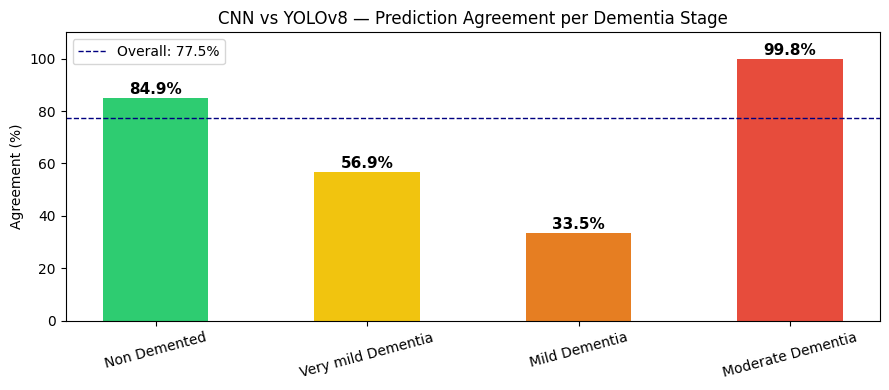

✅ Saved: benchmark_agreement.png


In [ ]:
agree_df = pd.DataFrame({
    'true':       y_true,
    'cnn_pred':   cnn_preds,
    'yolo_pred':  yolo_preds,
    'yolo_conf':  yolo_confs,
})
agree_df['agreement']   = agree_df['cnn_pred'] == agree_df['yolo_pred']
agree_df['both_correct'] = (
    (agree_df['cnn_pred']  == agree_df['true']) &
    (agree_df['yolo_pred'] == agree_df['true'])
)

# Per-class breakdown
print('Agreement per class:')
print('-' * 50)
for i, cls in enumerate(CLASS_NAMES):
    cls_df = agree_df[agree_df['true'] == i]
    agree_pct = cls_df['agreement'].mean() * 100
    both_pct  = cls_df['both_correct'].mean() * 100
    print(f'  {cls:<22}  Agreement: {agree_pct:5.1f}%   Both correct: {both_pct:5.1f}%')

print(f'\nOverall agreement  : {agreement*100:.2f}%')
print(f'Inter-model QWK    : {inter_qwk:.4f}  (1.0 = perfect consistency)')

# Bar chart
agree_by_class = [
    agree_df[agree_df['true'] == i]['agreement'].mean() * 100
    for i in range(4)
]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars   = ax.bar(CLASS_NAMES, agree_by_class, color=colors, width=0.5)
ax.set_ylim(0, 110)
ax.set_ylabel('Agreement (%)')
ax.set_title('CNN vs YOLOv8 — Prediction Agreement per Dementia Stage')
ax.tick_params(axis='x', rotation=15)
ax.axhline(y=agreement*100, color='navy', linestyle='--', linewidth=1, label=f'Overall: {agreement*100:.1f}%')
ax.legend()
for bar, val in zip(bars, agree_by_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()

fig.savefig(
    os.path.join(PROJECT_FOLDER, 'benchmark_agreement.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print('✅ Saved: benchmark_agreement.png')

## 13. Save All Results to Google Drive

In [ ]:
summary.to_csv(
    os.path.join(PROJECT_FOLDER, 'benchmark_summary.csv'), index=False
)
agree_df.to_csv(
    os.path.join(PROJECT_FOLDER, 'benchmark_predictions.csv'), index=False
)

print('✅ All results saved to Google Drive:')
print(f'   {PROJECT_FOLDER}/')
print('     benchmark_summary.csv')
print('     benchmark_predictions.csv')
print('     benchmark_confusion_matrices.png')
print('     benchmark_agreement.png')
print('     yolov8_dementia/weights/best.pt')

✅ All results saved to Google Drive:
   /content/drive/MyDrive/OASIS_Project/
     benchmark_summary.csv
     benchmark_predictions.csv
     benchmark_confusion_matrices.png
     benchmark_agreement.png
     yolov8_dementia/weights/best.pt
